In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [139]:
df=pd.read_csv(r'C:\Users\prati\Downloads\archive\vivek\indian_startups_funding.csv', encoding= 'unicode_escape')

In [157]:
df.head(10)

,Sr No,startup,vertical,city,investors,round,amount,year,state
0,1,#Fame,Media,Mumbai,To the new ventures,Private Equity,82.50,2015,Maharashtra
1,2,1mg,Healthcare,Gurugram,"Deep kalra, Sequoia capital, Omidyar network, ...",Private Equity,49.50,2015,Haryana
2,3,20Dresses,Personal Care,Mumbai,"Srinivas aluri, Srinivas modukury, Bs nagesh",Seed Funding,8.25,2015,Maharashtra
3,4,33Coupons,Marketing,Kanpur,Undisclosed,Seed Funding,0.17,2015,Uttar Pradesh
4,5,6Degree,Networking,Mumbai,Centre for incubation & business acceleration ...,Seed Funding,0.00,2015,Maharashtra
5,6,aagaar,Food,Gurugram,Group of investors,Seed Funding,0.00,2015,Haryana
6,7,Aasaanjobs,Careers,Mumbai,"Inventus capital partners, Idg ventures",Seed Funding,12.38,2015,Maharashtra
7,8,Abhibus,Travel,Hyderabad,Paytm (one97 communications),Private Equity,0.00,2015,Telangana
8,9,Absentia,Technology,Bengaluru,"Astarc ventures, 50k ventures & others",Seed Funding,1.49,2015,Karnataka
9,10,Actionable Analytics,Data Analytics,New Delhi,"B m gupta, Vinod singhal",Seed Funding,0.00,2015,Delhi


In [159]:
df.shape

(5074, 9)

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5074 entries, 0 to 5073
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Sr No      5074 non-null   int64  
 1   startup    5074 non-null   object 
 2   vertical   5074 non-null   object 
 3   city       5074 non-null   object 
 4   investors  5070 non-null   object 
 5   round      5074 non-null   object 
 6   amount     5074 non-null   float64
 7   year       5074 non-null   int64  
 8   state      5074 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 356.9+ KB


In [147]:
pd.isnull(df).sum()

Unnamed: 0    0
Sr No         0
startup       0
vertical      0
city          0
investors     4
round         0
amount        0
year          0
state         0
dtype: int64

In [149]:
df=df.drop(columns=['Unnamed: 0'], axis=1)

In [151]:
df.columns

Index(['Sr No', 'startup', 'vertical', 'city', 'investors', 'round', 'amount',
       'year', 'state'],
      dtype='object')

In [153]:
# 1 WORD FOR MANY ex., 'Undisclosed'='Undisclosed','Undisclosed investors','Undisclosed investor','Not disclosed','Unidisclosed'

df['investors']= df['investors'].replace({
    'Undisclosed': 'Undisclosed',
    'Undisclosed investors':
    'Undisclosed',
    'Undisclosed investor': 'Unidisclosed',
    'Not disclosed': 'Undisclosed',
    'Unidisclosed': 'Undisclosed'
})

In [155]:
#1 WORD USE FOR MANY ex., 'Seed Funding' = 'Seed Funding','Seed','Seed Round'

df['round']=df['round'].str.strip()

round_mapping = {
    'Seed Funding': 'Seed Funding',
    'Seed': 'Seed Funding',
    'Seed Round': 'Seed Funding',
    'Seed/ Angel Funding': 'Seed/Angel Funding',
    'Seed / Angel Funding': 'Seed/Angel Funding',
    'Seed/Angel Funding': 'Seed/Angel Funding',
    'Angel': 'Seed/Angel Funding',
    'Angel / Seed Funding': 'Seed/Angel Funding',
    'Private Equity': 'Private Equity',
    'Debt Financing': 'Debt Funding',
    'Debt Funding': 'Debt Funding'
}

In [31]:
df.head()

,Sr No,startup,vertical,city,investors,round,amount,year,state
0,1,#Fame,Media,Mumbai,To the new ventures,Private Equity,82.50,2015,Maharashtra
1,2,1mg,Healthcare,Gurugram,"Deep kalra, Sequoia capital, Omidyar network, ...",Private Equity,49.50,2015,Haryana
2,3,20Dresses,Personal Care,Mumbai,"Srinivas aluri, Srinivas modukury, Bs nagesh",Seed Funding,8.25,2015,Maharashtra
3,4,33Coupons,Marketing,Kanpur,Undisclosed,Seed Funding,0.17,2015,Uttar Pradesh
4,5,6Degree,Networking,Mumbai,Centre for incubation & business acceleration ...,Seed Funding,0.00,2015,Maharashtra


In [33]:
df.drop(columns=['Sr No'], inplace=True)

In [35]:
df.columns

Index(['startup', 'vertical', 'city', 'investors', 'round', 'amount', 'year',
       'state'],
      dtype='object')

In [37]:
df['city'] = df['city'].replace({'Bengaluru':'Banglore', 'Gurugram':'Gurgaon'})

In [39]:
df.head(10)

,startup,vertical,city,investors,round,amount,year,state
0,#Fame,Media,Mumbai,To the new ventures,Private Equity,82.50,2015,Maharashtra
1,1mg,Healthcare,Gurgaon,"Deep kalra, Sequoia capital, Omidyar network, ...",Private Equity,49.50,2015,Haryana
2,20Dresses,Personal Care,Mumbai,"Srinivas aluri, Srinivas modukury, Bs nagesh",Seed Funding,8.25,2015,Maharashtra
3,33Coupons,Marketing,Kanpur,Undisclosed,Seed Funding,0.17,2015,Uttar Pradesh
4,6Degree,Networking,Mumbai,Centre for incubation & business acceleration ...,Seed Funding,0.00,2015,Maharashtra
5,aagaar,Food,Gurgaon,Group of investors,Seed Funding,0.00,2015,Haryana
6,Aasaanjobs,Careers,Mumbai,"Inventus capital partners, Idg ventures",Seed Funding,12.38,2015,Maharashtra
7,Abhibus,Travel,Hyderabad,Paytm (one97 communications),Private Equity,0.00,2015,Telangana
8,Absentia,Technology,Banglore,"Astarc ventures, 50k ventures & others",Seed Funding,1.49,2015,Karnataka
9,Actionable Analytics,Data Analytics,New Delhi,"B m gupta, Vinod singhal",Seed Funding,0.00,2015,Delhi


In [41]:
df.dropna(subset=['investors'],inplace=True)

In [43]:
df.shape

(5070, 8)

In [45]:
df=df[df['amount'] != 0.00]

In [47]:
df.shape

(3472, 8)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3472 entries, 0 to 5072
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   startup    3472 non-null   object 
 1   vertical   3472 non-null   object 
 2   city       3472 non-null   object 
 3   investors  3472 non-null   object 
 4   round      3472 non-null   object 
 5   amount     3472 non-null   float64
 6   year       3472 non-null   int64  
 7   state      3472 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 244.1+ KB


In [51]:
df.shape

(3472, 8)

In [53]:
df = df.drop_duplicates(subset=['startup','year'], keep='first')

In [55]:
df.shape

(3112, 8)

In [57]:
df.rename(columns={'amount':'amount crores'}, inplace=True)

In [59]:
df.rename(columns={'vertical':'industry'}, inplace=True)

In [61]:
df.head(10) 

,startup,industry,city,investors,round,amount crores,year,state
0,#Fame,Media,Mumbai,To the new ventures,Private Equity,82.50,2015,Maharashtra
1,1mg,Healthcare,Gurgaon,"Deep kalra, Sequoia capital, Omidyar network, ...",Private Equity,49.50,2015,Haryana
2,20Dresses,Personal Care,Mumbai,"Srinivas aluri, Srinivas modukury, Bs nagesh",Seed Funding,8.25,2015,Maharashtra
3,33Coupons,Marketing,Kanpur,Undisclosed,Seed Funding,0.17,2015,Uttar Pradesh
6,Aasaanjobs,Careers,Mumbai,"Inventus capital partners, Idg ventures",Seed Funding,12.38,2015,Maharashtra
8,Absentia,Technology,Banglore,"Astarc ventures, 50k ventures & others",Seed Funding,1.49,2015,Karnataka
10,AdStringO,Marketing,Mumbai,"Arihant patni, Vishal khare, viswanath ramach...",Seed Funding,2.89,2015,Maharashtra
11,AdWyze,Marketing,Banglore,Mape advisory,Seed Funding,8.25,2015,Karnataka
12,AgentDesks,Real Estate,Gurgaon,"Sierra ventures, Cota capital, Vegas tech fund",Seed Funding,24.34,2015,Haryana
13,Agrostar,AgriTech,Pune,Idg ventures,Private Equity,33.00,2015,Maharashtra


In [63]:
df['startup'] =df['startup'].str.replace('#','',regex=False)

In [65]:
df.head(10)

,startup,industry,city,investors,round,amount crores,year,state
0,Fame,Media,Mumbai,To the new ventures,Private Equity,82.50,2015,Maharashtra
1,1mg,Healthcare,Gurgaon,"Deep kalra, Sequoia capital, Omidyar network, ...",Private Equity,49.50,2015,Haryana
2,20Dresses,Personal Care,Mumbai,"Srinivas aluri, Srinivas modukury, Bs nagesh",Seed Funding,8.25,2015,Maharashtra
3,33Coupons,Marketing,Kanpur,Undisclosed,Seed Funding,0.17,2015,Uttar Pradesh
6,Aasaanjobs,Careers,Mumbai,"Inventus capital partners, Idg ventures",Seed Funding,12.38,2015,Maharashtra
8,Absentia,Technology,Banglore,"Astarc ventures, 50k ventures & others",Seed Funding,1.49,2015,Karnataka
10,AdStringO,Marketing,Mumbai,"Arihant patni, Vishal khare, viswanath ramach...",Seed Funding,2.89,2015,Maharashtra
11,AdWyze,Marketing,Banglore,Mape advisory,Seed Funding,8.25,2015,Karnataka
12,AgentDesks,Real Estate,Gurgaon,"Sierra ventures, Cota capital, Vegas tech fund",Seed Funding,24.34,2015,Haryana
13,Agrostar,AgriTech,Pune,Idg ventures,Private Equity,33.00,2015,Maharashtra


In [67]:
#EXPLORATORY ANALYSIS

In [69]:
#(1) TOTAL FUNDING AMOUNT

Total_crores = df['amount crores'].sum() 
print(f"Total Funding: {Total_crores:,.2f} Crores")

Total Funding: 561,429.71 Crores


In [71]:
#(2) TOP 10 HIGHEST FUNDING STARTUPS

top_startups = df.groupby('startup')['amount crores'].sum().sort_values(ascending=False).head(10)
print (top_startups)

#1. BYJU'S = 24195.00 Crores

startup
BYJU'S              24195.00
Swiggy              12838.88
Flipkart            11506.75
Ninjacart            9084.63
Udaan                9015.00
GalaxyCard           8300.00
MoooFarm             8300.00
Krimanshi Feeds      8300.00
VerSe Innovation     8300.00
Paytm                7957.34
Name: amount crores, dtype: float64


In [73]:
#(3) LOWEST FUNDING 10 STARTUPS

lowest_10_startups = df.groupby('startup')['amount crores'].sum().sort_values(ascending=True).head(10)
print (lowest_10_startups)

#1. Pixr9 = 0.01 crores [ 1 lakh ]

startup
Pixr9                                       0.01
Classworks India                            0.02
Next Digital Solutions                      0.02
ENLYFT DIGITAL SOLUTIONS PRIVATE LIMITED    0.04
AuthMetrik                                  0.07
Mombay                                      0.08
Sqrrl FinTech                               0.10
artbandhu                                   0.11
Play your sport                             0.13
CBS                                         0.13
Name: amount crores, dtype: float64


In [75]:
#(4) AVEARGE FUNDING OF STARTUP

"{:.2f}".format(df['amount crores'].mean())

#180.41 Crores

'180.41'

In [77]:
#(5) MOST FUNDING RECEIVED 10 CITY

df.groupby('city')['amount crores'].sum().sort_values(ascending=False).head(10)

#Banglore with 227220.55 Crores

city
Banglore     227220.55
Mumbai       111717.96
Gurgaon       77469.52
New Delhi     46453.59
Chennai       19753.97
Pune          12551.93
Noida         10911.87
Hyderabad      9936.48
Jodhpur        8302.32
Thane          7899.63
Name: amount crores, dtype: float64

In [79]:
#(6) STARTUPS FROM EACH CITY

df['city'].value_counts() 

city
Banglore       1008
Mumbai          617
Gurgaon         399
New Delhi       395
Chennai         136
Hyderabad       117
Pune            113
Noida            95
Ahmedabad        41
Jaipur           37
Kolkata          27
Indore           13
Haryana          12
Goa              10
Vadodara          7
Coimbatore        6
Chandigarh        5
Bhopal            5
Kanpur            5
Thane             4
Belgaum           4
Kochi             4
Jodhpur           4
Ghaziabad         3
Andheri           3
Surabardi         3
Faridabad         3
Alleppey          2
Bangalore         2
Kannur            2
Bhubaneswar       2
Kota              2
Patna             2
Trivandrum        2
Guntur            2
Chembur           1
Amritsar          1
Dhingsara         1
Kurawar           1
Surat             1
Tirunelveli       1
Bangaluru         1
Cochin            1
Kerala            1
Nagpur            1
Udaipur           1
Panaji            1
Gaya              1
Gwalior           1
Mussoorie      

In [81]:
#(7) TOP 10 INVESTORS INVEST IN MAXIMUM STARTUPS

df['investors'].value_counts().head(10)

#UNDISCLOSED INVESTORS ARE MOST INVESTED.

investors
Undisclosed                 711
Unidisclosed                 20
Group of angel investors     15
Kalaari capital              13
Indian angel network         12
Sequoia capital              11
Saif partners                10
Info edge (india) ltd         9
Accel partners                9
Brand capital                 8
Name: count, dtype: int64

In [83]:
#(8) TOTAL FUNDING PER YEAR

df.groupby('year')['amount crores'].sum()

year
2015     60898.01
2016     29369.57
2017     34198.21
2018     39420.17
2019     36474.20
2020    296362.74
2021     64706.81
Name: amount crores, dtype: float64

In [85]:
#(9) INDUSTRY THAT RECEIVED MOST FUNDING

df.groupby('industry')['amount crores'].sum().sort_values(ascending=False).head(10)

#E-COMMERCE WITH 77671.72 CRORES

industry
E-Commerce           77671.72
FinTech              61849.36
EdTech               52465.22
Food                 42222.55
Finance              41705.89
AgriTech             30810.60
Technology           30048.09
Healthcare           26999.17
Consumer Internet    20728.51
Logistics            20240.53
Name: amount crores, dtype: float64

In [87]:
#(10) DISTRIBUTION OF FUNDING ROUNDS BY STARTUPS

df['round'] = df['round'].replace(round_mapping)
print(df['round'].value_counts().head())

round
Seed Funding          1002
Private Equity         977
Undisclosed            628
Seed/Angel Funding     134
Series A               122
Name: count, dtype: int64


In [89]:
#(11) STARTUPS THAT RECEIVED FUNDING MORE THAN 100 CRORES

df[df['amount crores'] > 100].head(15)

,startup,industry,city,investors,round,amount crores,year,state
16,Akosha,Technology,New Delhi,Sequoia capital,Private Equity,132.00,2015,Delhi
18,Allygrow Technologies,Technology,Mumbai,Zodius technology fund,Private Equity,165.00,2015,Maharashtra
26,Antuit,Data Analytics,Banglore,"Goldman sachs, Zodius capital",Private Equity,462.00,2015,Karnataka
30,Applied Solar Technologies,Energy,Mumbai,"Future fund, Bessemer venture, Capricorn inves...",Private Equity,330.00,2015,Maharashtra
32,Appsdaily,Technology,Mumbai,"Zodius capital, Ru-net, Kalaari capital, qual...",Private Equity,132.00,2015,Maharashtra
36,Arkin Net,Data Analytics,Pune,Nexus venture partners,Private Equity,123.75,2015,Maharashtra
41,Aryaka,Technology,Banglore,"Trinity ventures, Interwest partners, Mohr dav...",Private Equity,132.00,2015,Karnataka
47,Axtria,Data Analytics,Gurgaon,"Helion venture partners, Amarpreet sawhney, De...",Private Equity,247.50,2015,Haryana
52,BankBazaar,FinTech,Chennai,"Amazon, Fidelity growth partners, Mousse partners",Private Equity,495.00,2015,Tamil Nadu
61,Bidgely,Energy,Banglore,Constellation technology ventures (exelon corp...,Private Equity,136.95,2015,Karnataka


In [91]:
#(12) TOP INVESTORS WHO FUNDED HIGHEST AMOUNT

df.groupby('investors')['amount crores'].sum().sort_values(ascending=False).head(10)

investors
Undisclosed                                       84006.16
Owl Ventures, Tiger Global Management             16650.00
Google                                             8401.48
Canaan Partners, NewView Capital                   8300.00
Poonawalla, Allana Group                           8300.00
Tiger Global Management, Sequoia Capital India     8300.00
Alibaba Group, InnoVen Capital                     8300.00
Small Industries Development Bank of India         6640.00
General Catalyst, Ribbit Capital                   6640.00
General Atlantic, Kohlberg Kravis Roberts          6640.00
Name: amount crores, dtype: float64

In [93]:
#(13) NUMBER OF STARTUPS FUNDED EACH YEAR

df['year'].value_counts().sort_index()

year
2015    590
2016    551
2017    415
2018    464
2019     95
2020    624
2021    373
Name: count, dtype: int64

In [95]:
#(14) STARTUPS THAT RECEIVED FUNDUNG LESS THAN 10 CRORES

df[df['amount crores'] < 10.00].shape

#1353 STARTUPS

(1353, 8)

In [97]:
#(15) STARTUPS THAT RECEIVED FUNDUNG MORE THAN 100 CRORES

df[df['amount crores'] > 100.00].shape

#685 STARTUPS

(685, 8)

In [99]:
#VISUALISATION DONE FROM HERE

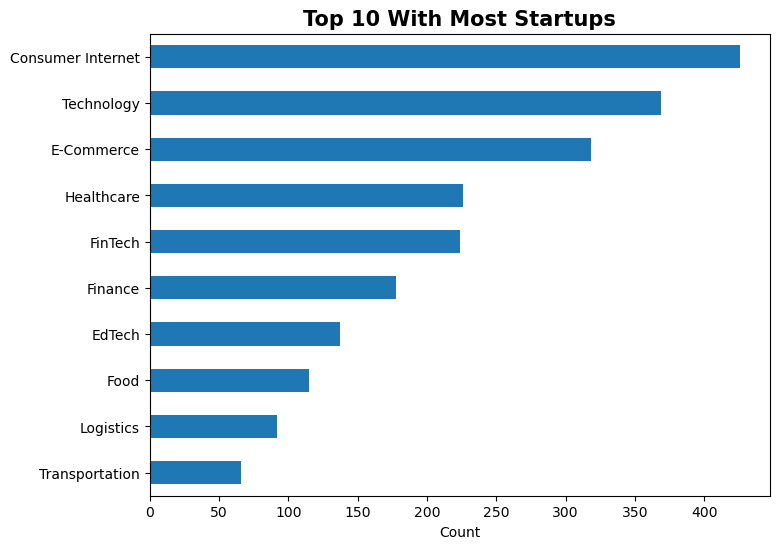

In [101]:
#(1) TOP 10 CITIES / INDUSTRY / STATES WITH MOST STARTUPS (BARH CHART)

df['industry'].value_counts().head(10).plot(kind='barh',figsize=(8,6))
plt.title("Top 10 With Most Startups",fontsize=15, fontweight='bold')
plt.xlabel("Count")
plt.ylabel("") 
plt.gca().invert_yaxis()
plt.show()

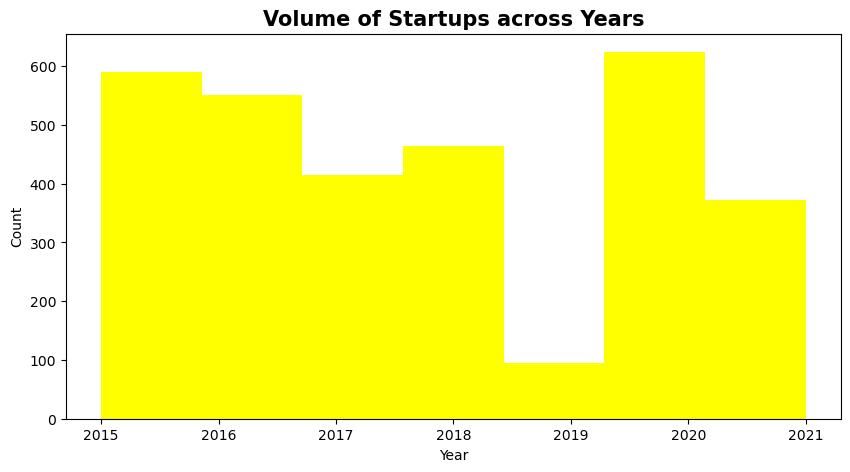

In [103]:
#DISTRIBUTION OF STARTUPS YEAR TO YEAR (HISTOGRAM CHART)

plt.figure(figsize=(10,5))
plt.hist(df['year'], 
bins=len(df['year'].unique()), color='yellow')
plt.title("Volume of Startups across Years",fontsize=15, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

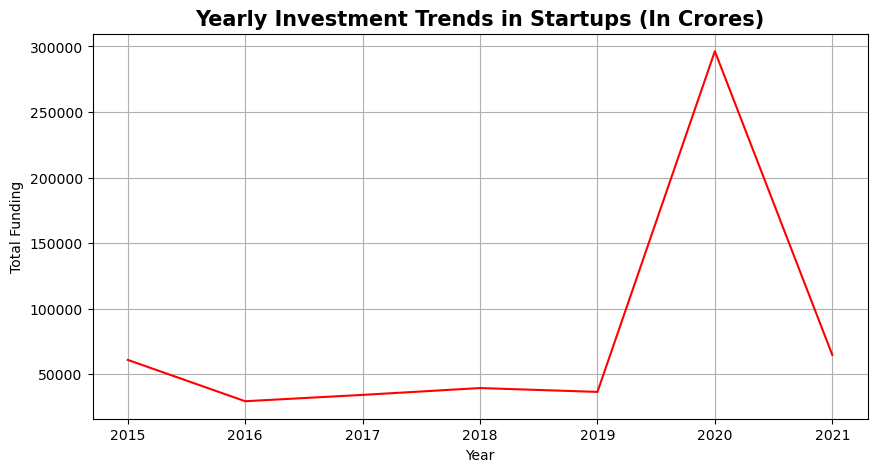

In [104]:
#FLOW OF STARTUP INVESTMENT OVER YEARS (TREND CHART)

year_trend = df.groupby('year')['amount crores'].sum()
plt.figure(figsize=(10,5))
plt.plot(year_trend.index,year_trend.values, color='red')
plt.title("Yearly Investment Trends in Startups (In Crores)",fontsize=15, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Total Funding")
plt.grid(True)
plt.show()

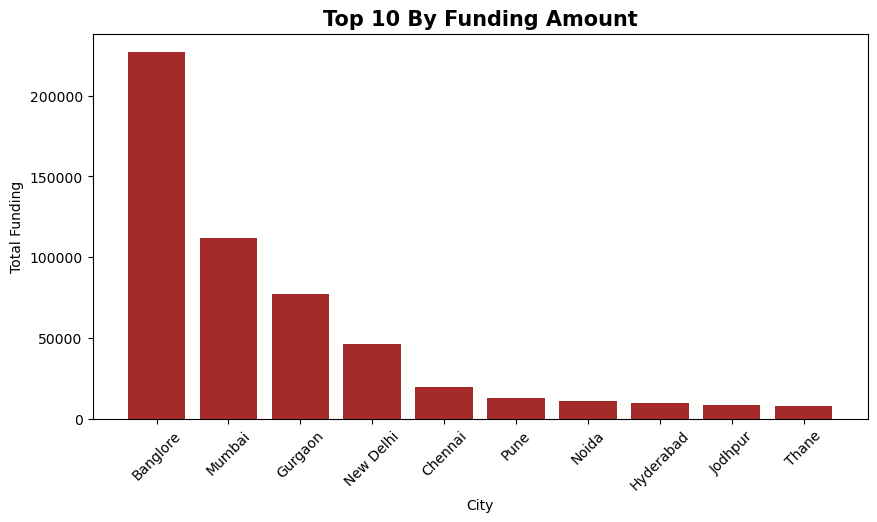

In [107]:
#TOP 10 CITIES / STATES / INDUSTRYY BY INVESTMENT AMOUNT (BAR CHART)

city_funding = df.groupby('city')['amount crores'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(city_funding.index,city_funding.values, color='brown')
plt.title("Top 10 By Funding Amount",fontsize=15, fontweight='bold')
plt.xlabel("City")
plt.ylabel("Total Funding")
plt.xticks(rotation=45)
plt.show()

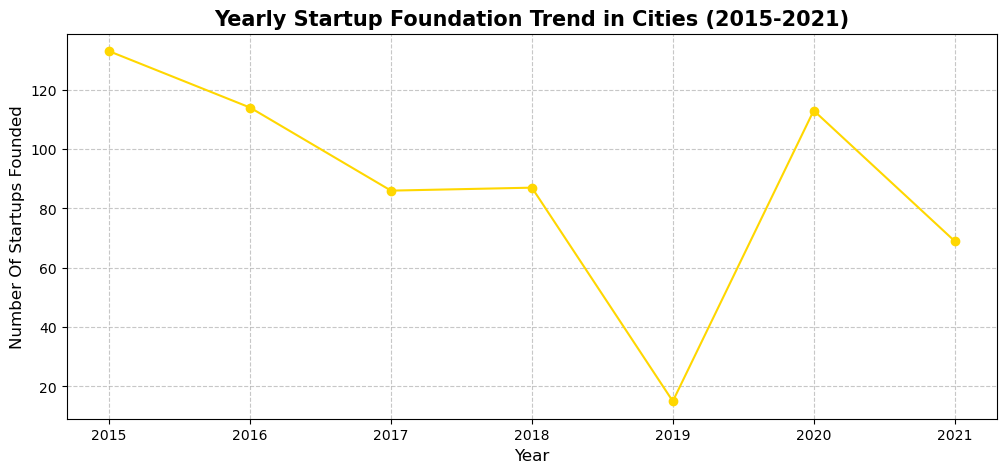

In [109]:
#YEARLY EVOLUTION OF STARTUP FOUNDATION IN CITIES (TREND CHART)

cities_trend = df[df['city'] == 'Mumbai'].groupby('year')['startup'].count()
plt.figure(figsize=(12,5))
plt.plot(cities_trend.index,cities_trend.values,color='gold',marker='o')
plt.title("Yearly Startup Foundation Trend in Cities (2015-2021)",fontsize=15, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number Of Startups Founded", fontsize=12)
plt.grid(True, linestyle='--',alpha=0.7)
plt.show()

In [112]:
# TOTAL FUNDING PREDICTION BY YEAR (LINEAR REGRESSION)

yearly = df.groupby('year')['amount crores'].sum().reset_index()
X = yearly['year'].values.reshape(-1,1)
y = yearly['amount crores'].values
model = LinearRegression()
model.fit(X, y)
future_years = np.array([2023]).reshape(-1,1)
predictions = model.predict(future_years)
np.set_printoptions(precision= 2,suppress=True)
print(predictions)

[178005.8]


In [114]:
# STARTUPS COUNT PREDICTION BY YEAR (LINEAR REGRESSION)

count_year = df['year'].value_counts().sort_index().reset_index()
count_year.columns = ['year', 'startup_count']
X = count_year[['year']]
y = count_year['startup_count']
model = LinearRegression()
model.fit(X, y)
future_years = pd.DataFrame({'year':[2028]})
future_startups = model.predict(future_years)
future_startups_rounded = future_startups.round().astype(int)
future_startups_rounded

array([150])

In [117]:
df.to_csv('processed_startup_data.csv',index=False)
print("File saved successfully!")

File saved successfully!
